In [26]:
import os, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import glob, math
from scipy import signal
from scipy.fft import rfft, rfftfreq
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (20, 18)
%matplotlib inline

In [27]:
# Remove junk files starting with "._" using the CLI command: 
# "Get-ChildItem -Recurse -Filter "._*" | Remove-Item"

In [28]:
# data_path = "../NeurIT/NeurIT-dataset/uniform_data/"
data_path = "../data/raw_data/"
# print(os.path.exists(data_path))

splits = ["test_seen", "test_unseen", "train_dataset", "val_dataset"]
for split in splits:
    split_path = os.path.join(data_path, split)
    offices = os.listdir(split_path)
    print(split, "→", len(offices), "office folders")

test_seen → 15 office folders
test_unseen → 19 office folders
train_dataset → 60 office folders
val_dataset → 15 office folders


In [29]:
def load_sample(split):
    split_path = os.path.join(data_path, split)
    office = os.listdir(split_path)[0]
    folder = os.path.join(split_path, office)

    raw = np.load(os.path.join(folder, "rawdata.npy"))
    gt = np.load(os.path.join(folder, "groundtruth.npy"))

    return raw, gt, office

for split in splits:
    raw, gt, office = load_sample(split)
    print(f"{split:<{13}} | {office:<{13}} | raw_shape={raw.shape} | gt_shape={gt.shape}")

test_seen     | 101office1    | raw_shape=(70895, 10) | gt_shape=(70895, 8)
test_unseen   | cyc3floor1    | raw_shape=(74789, 10) | gt_shape=(74789, 8)
train_dataset | 101office1    | raw_shape=(44452, 10) | gt_shape=(44452, 8)
val_dataset   | 101office1    | raw_shape=(89010, 10) | gt_shape=(89010, 8)


##### The raw data has 10 features:
- 1 represents timestamps
- 3 from gyroscope
- 3 from accelerometer
- 3 from magnetometer
(in order)
---
##### The ground truth has 8 features:
- 1 represents timestamps
- position - 3D
- orientation - 4D(quaternions)
(in order)

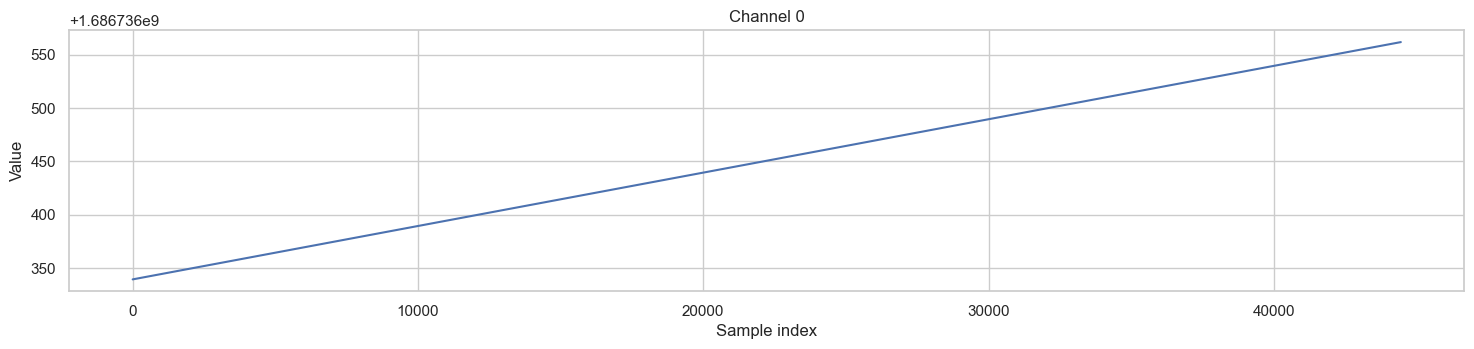

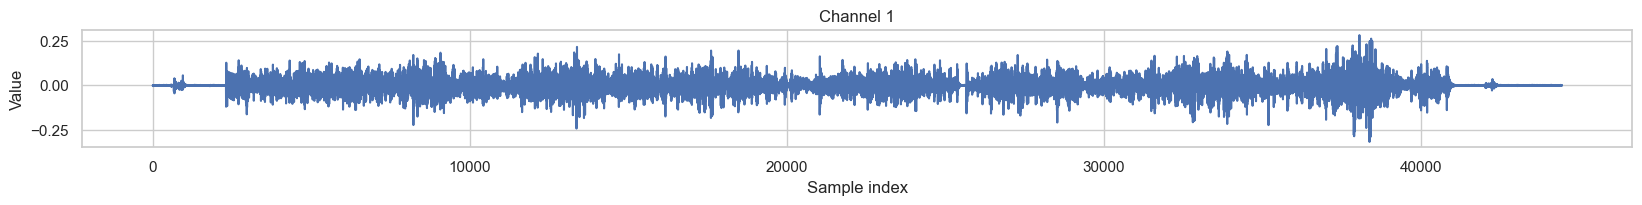

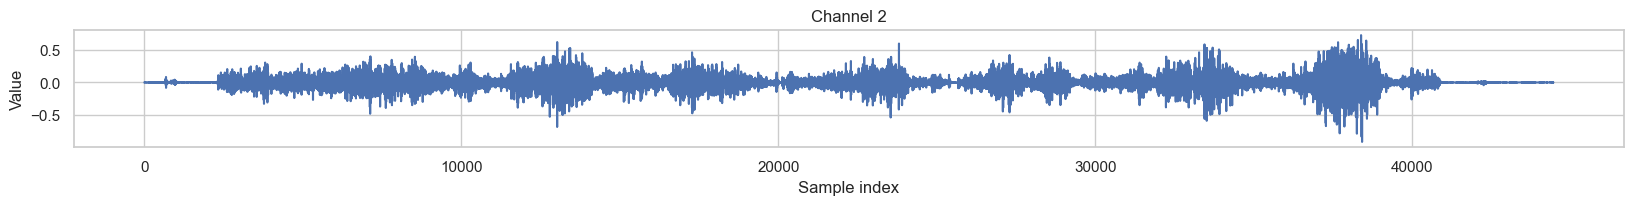

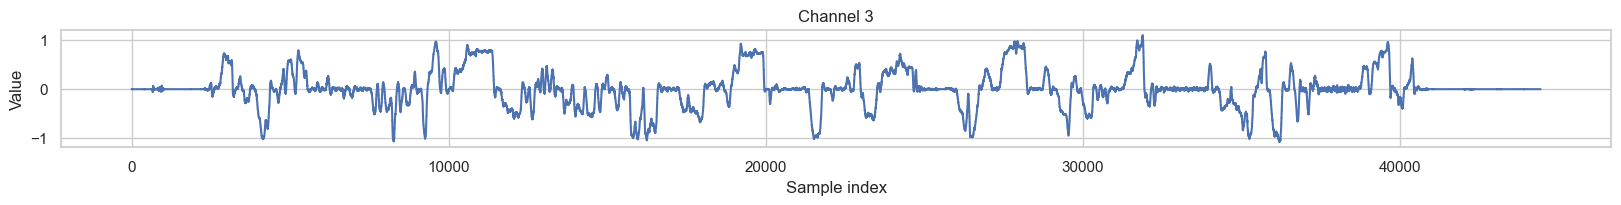

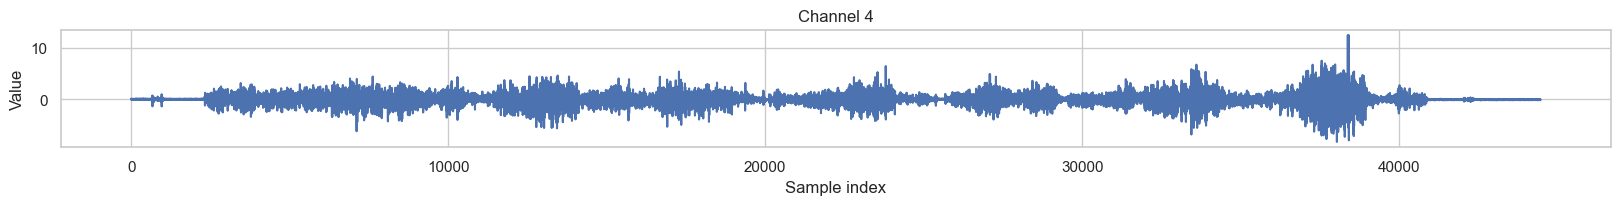

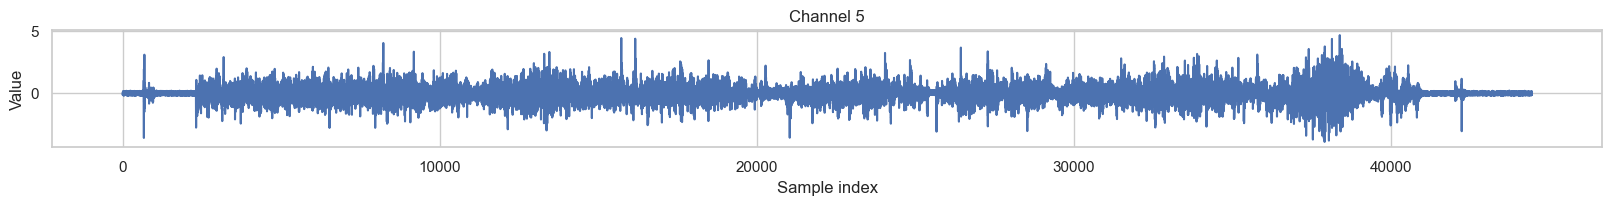

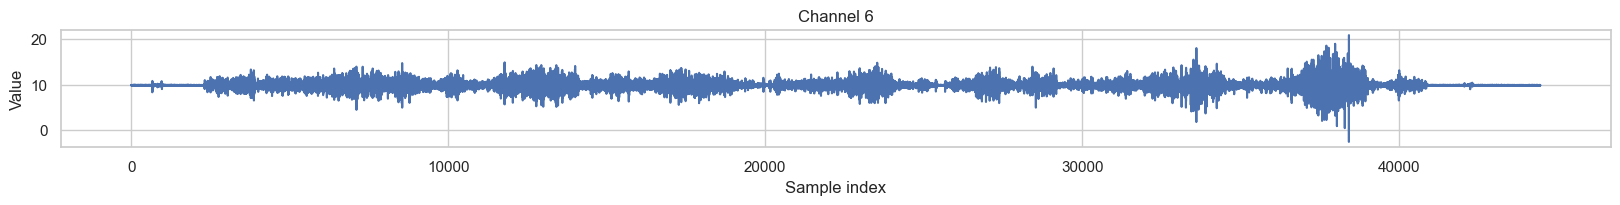

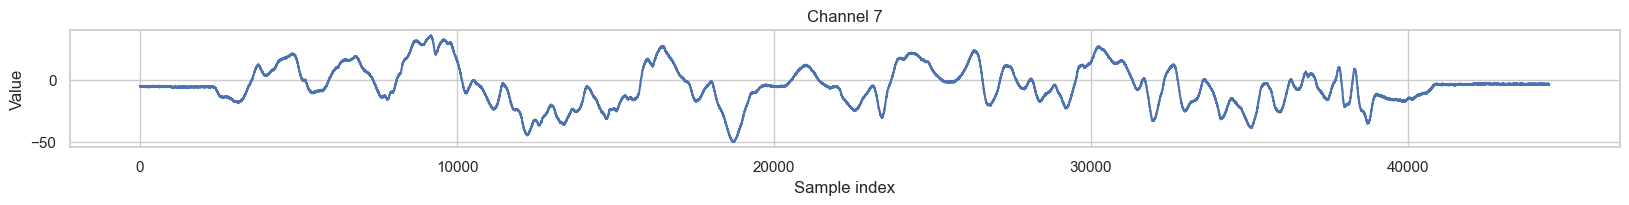

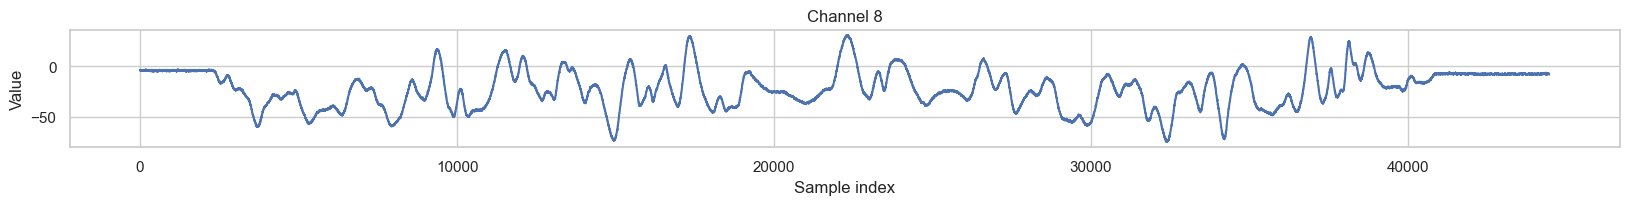

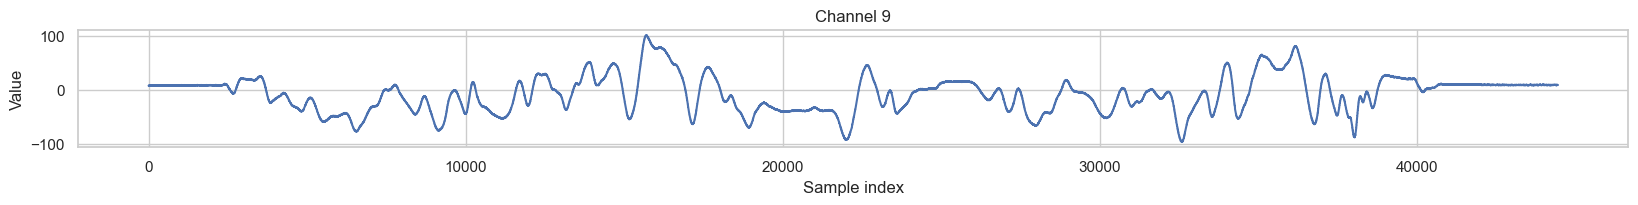

In [30]:
raw, gt, office = load_sample("train_dataset")

num_channels_to_plot =  raw.shape[1]

plt.figure(figsize=(18, 4 * num_channels_to_plot))

for i in range(num_channels_to_plot):
    plt.subplot(num_channels_to_plot, 1, i + 1)
    plt.plot(raw[:, i])
    plt.title(f"Channel {i}")
    plt.xlabel("Sample index")
    plt.ylabel("Value")
    # plt.tight_layout()
    plt.show()

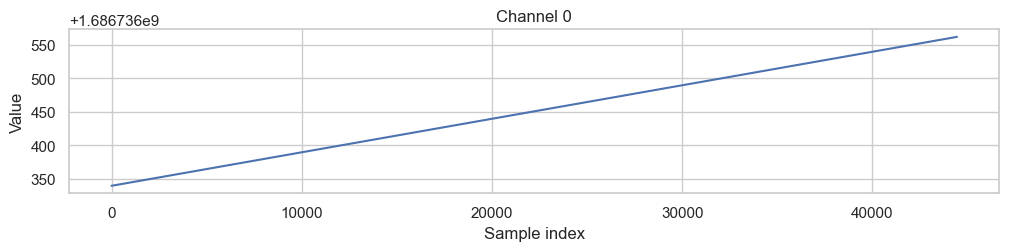

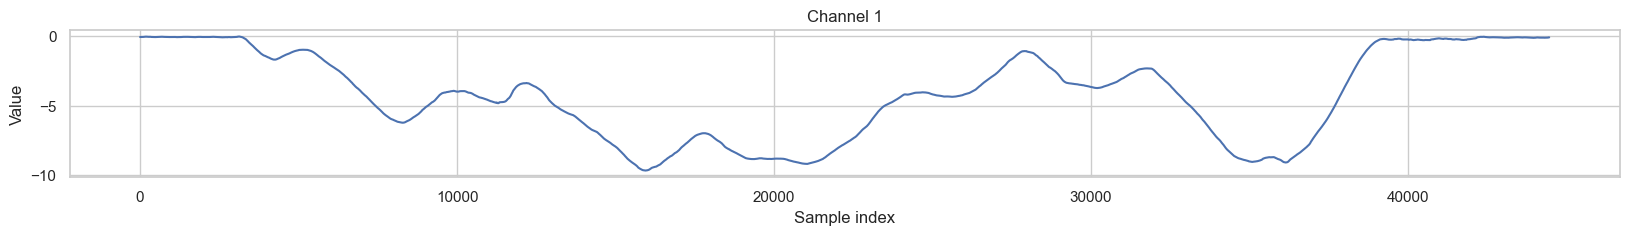

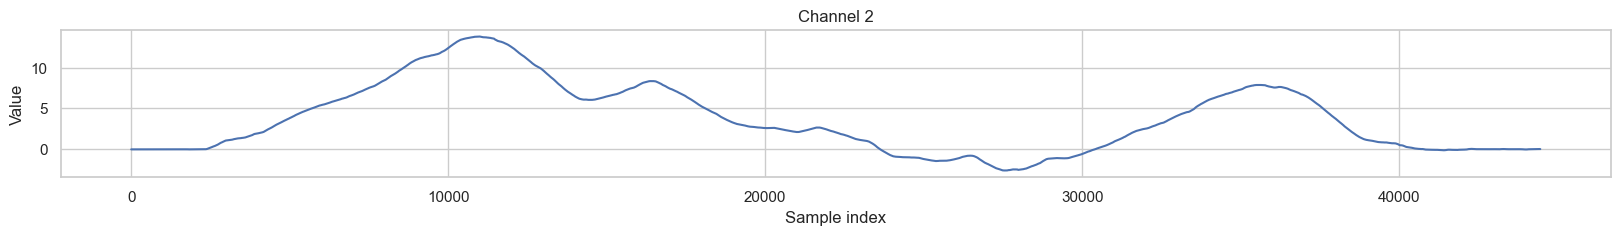

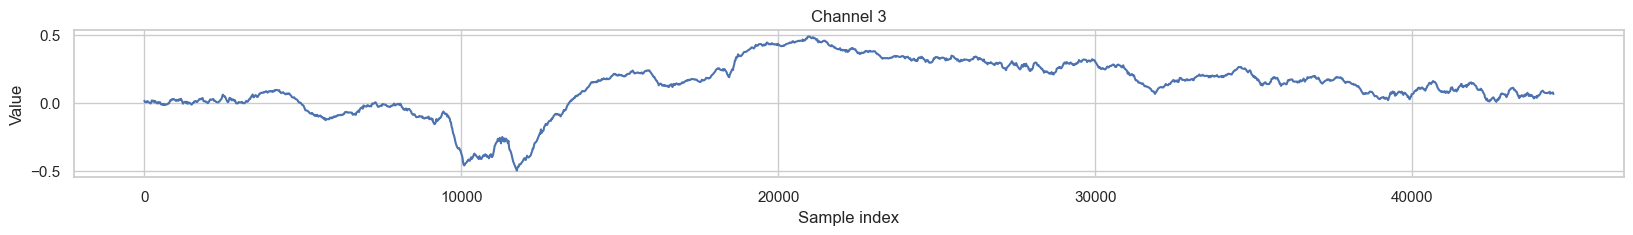

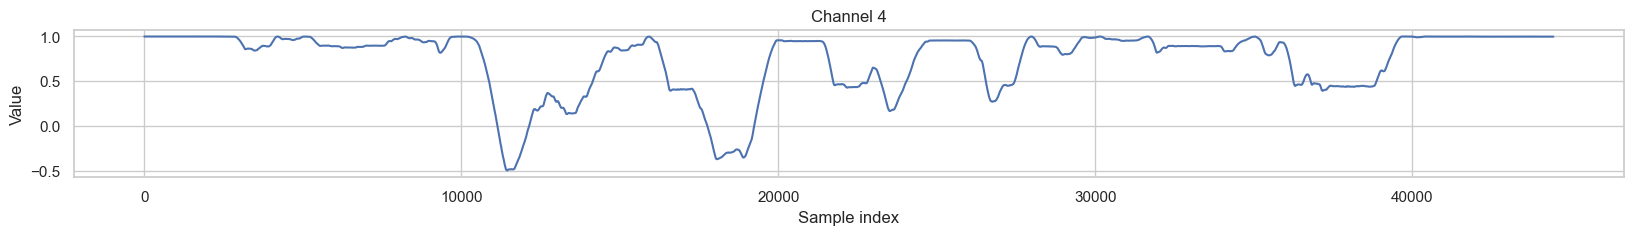

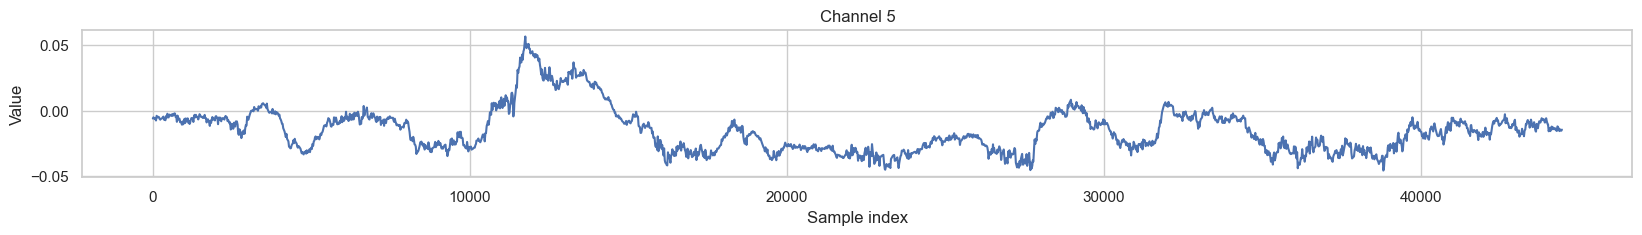

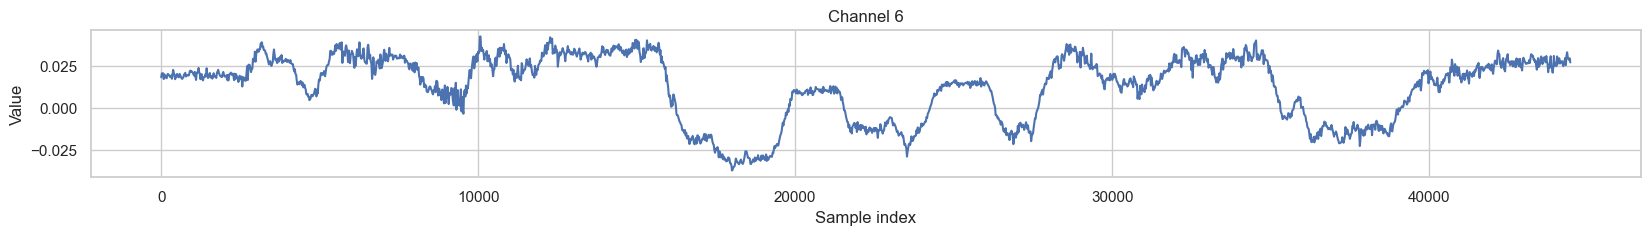

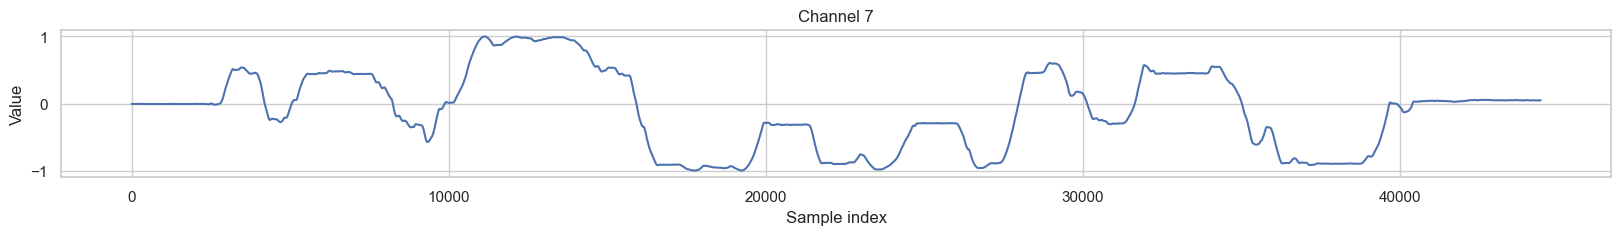

In [31]:
num_channels_to_plot =  gt.shape[1]

plt.figure(figsize=(12, 2.5 * num_channels_to_plot))

for i in range(num_channels_to_plot):
    plt.subplot(num_channels_to_plot, 1, i + 1)
    plt.plot(gt[:, i])
    plt.title(f"Channel {i}")
    plt.xlabel("Sample index")
    plt.ylabel("Value")
    # plt.tight_layout()
    plt.show()

In [32]:
raw, gt, office = load_sample("train_dataset")

timestamp = raw[:, 0]
gyro = raw[:, 1:4]
acce = raw[:, 4:7]
mag  = raw[:, 7:10]

gt_time = gt[:, 0]
pos = gt[:, 1:4]
quat = gt[:, 4:8]


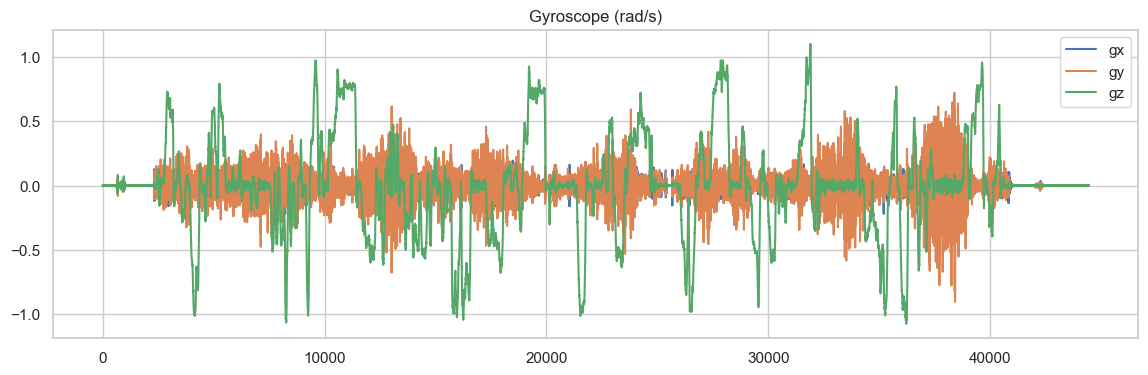

In [33]:
plt.figure(figsize=(14,4))
plt.plot(gyro[:,0], label="gx")
plt.plot(gyro[:,1], label="gy")
plt.plot(gyro[:,2], label="gz")
plt.legend()
plt.title("Gyroscope (rad/s)")
plt.show()

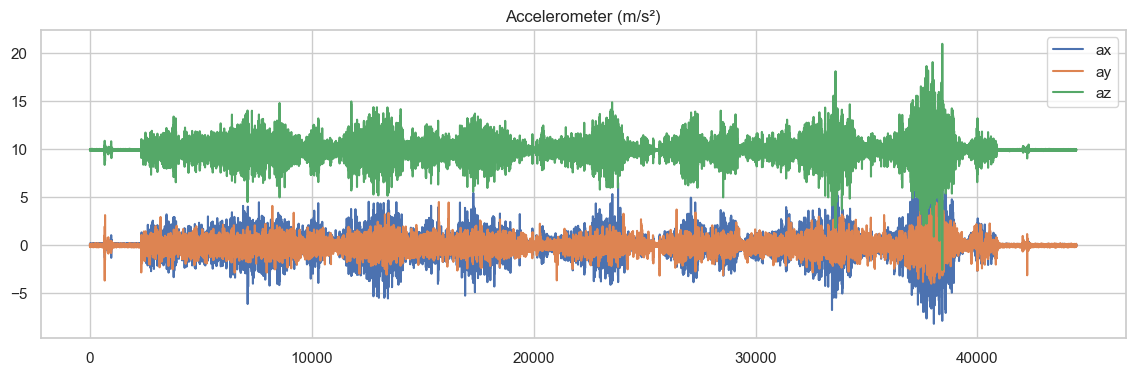

In [34]:
plt.figure(figsize=(14,4))
plt.plot(acce[:,0], label="ax")
plt.plot(acce[:,1], label="ay")
plt.plot(acce[:,2], label="az")
plt.legend()
plt.title("Accelerometer (m/s²)")
plt.show()

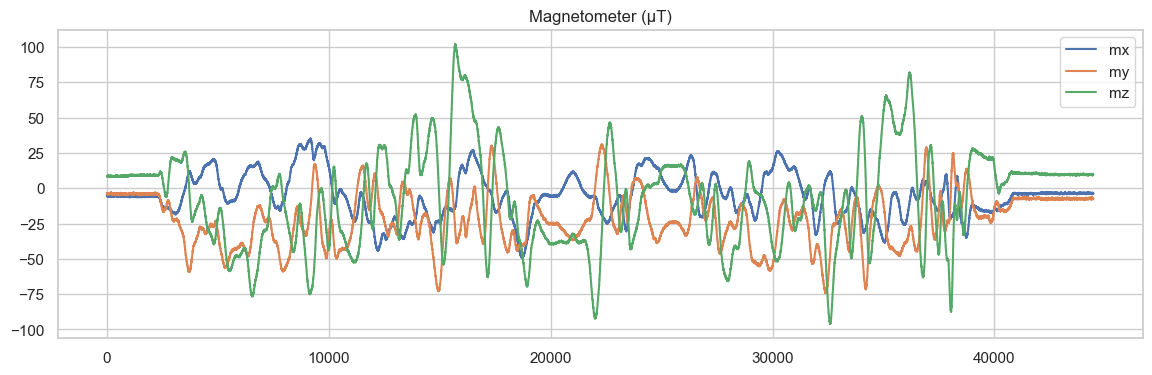

In [35]:
plt.figure(figsize=(14,4))
plt.plot(mag[:,0], label="mx")
plt.plot(mag[:,1], label="my")
plt.plot(mag[:,2], label="mz")
plt.legend()
plt.title("Magnetometer (µT)")
plt.show()

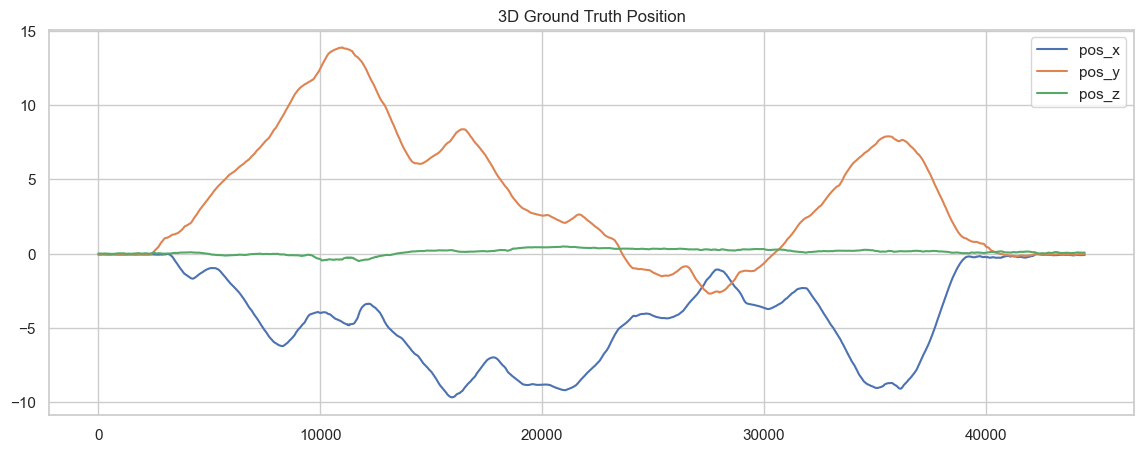

In [36]:
plt.figure(figsize=(14,5))
plt.plot(pos[:,0], label="pos_x")
plt.plot(pos[:,1], label="pos_y")
plt.plot(pos[:,2], label="pos_z")
plt.legend()
plt.title("3D Ground Truth Position")
plt.show()

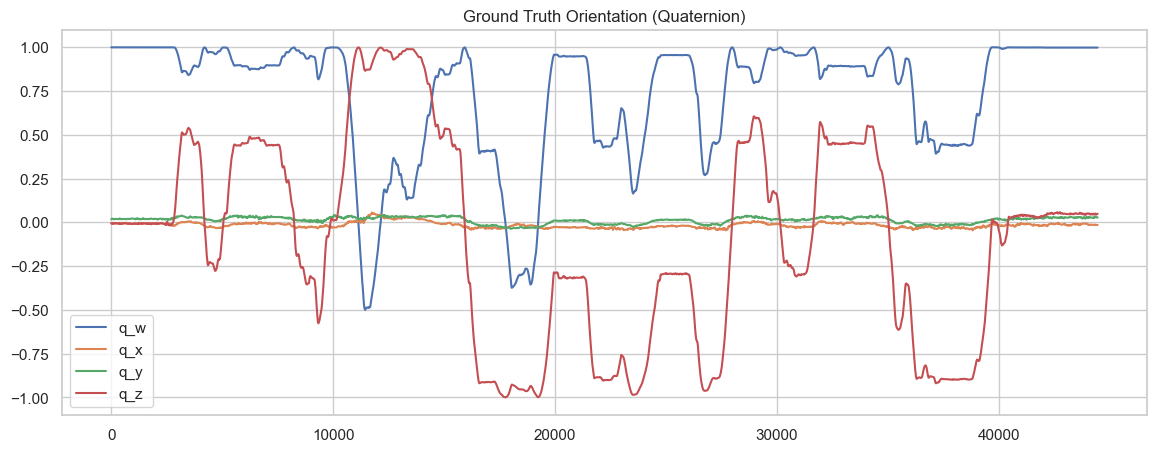

In [37]:
plt.figure(figsize=(14,5))
for i, comp in enumerate(["w", "x", "y", "z"]):
    plt.plot(quat[:, i], label=f"q_{comp}")

plt.legend()
plt.title("Ground Truth Orientation (Quaternion)")
plt.show()

dt mean: 0.005002921908052643 
dt std: 0.0018264650737779102
dt percentiles (1,25,50,75,99): [0.00193644 0.00398779 0.00484395 0.00601578 0.00806987]


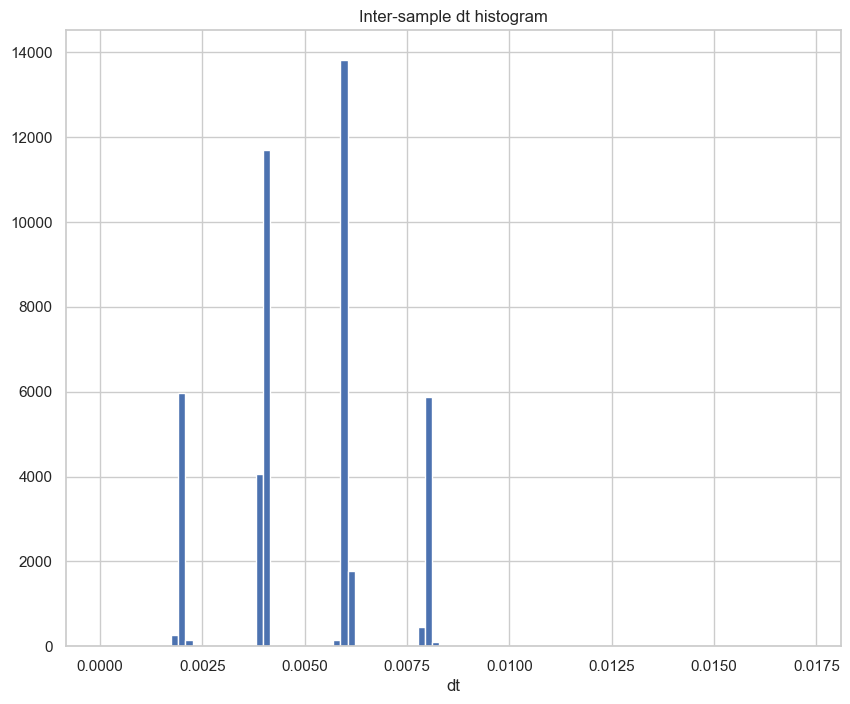

In [38]:
def sampling_stats(timestamp):
    dt = np.diff(timestamp)
    return dt.mean(), dt.std(), np.percentile(dt, [1,25,50,75,99])

dt_mean, dt_std, dt_pct = sampling_stats(timestamp)
print("dt mean:", dt_mean, "\ndt std:", dt_std)
print("dt percentiles (1,25,50,75,99):", dt_pct)

plt.figure(figsize=(10, 8))
plt.hist(np.diff(timestamp), bins=100)
plt.title("Inter-sample dt histogram")
plt.xlabel("dt")
plt.show()

- Mean sampling interval = ~5 ms = ~200Hz
- Sampling Jitter = 0.00182/0.005 = ~36% (high jitter)
    => Sampling intervals are not consistent.

In [39]:
def print_stats(name, data):
    print(f"\n{name} Stats:")
    print(" Mean:", data.mean(axis=0))
    print(" Std :", data.std(axis=0))
    print(" Min :", data.min(axis=0))
    print(" Max :", data.max(axis=0))

print_stats("Gyroscope", gyro)
print_stats("Accelerometer", acce)
print_stats("Magnetometer", mag)

print_stats("Position", pos)
print_stats("Quaternion", quat)


Gyroscope Stats:
 Mean: [1.45638201e-05 5.60296281e-05 5.90952723e-04]
 Std : [0.04525634 0.09982466 0.3674418 ]
 Min : [-0.31471565 -0.90752661 -1.07882004]
 Max : [0.28006021 0.72294207 1.10546263]

Accelerometer Stats:
 Mean: [ 2.93368803e-03 -6.78150117e-02  9.88372808e+00]
 Std : [1.11117968 0.70097124 1.05924984]
 Min : [-8.21799008 -4.04283056 -2.61528474]
 Max : [12.45320792  4.69768375 20.92336206]

Magnetometer Stats:
 Mean: [ -5.18721288 -21.76174546  -7.36964367]
 Std : [15.3052131  18.53690292 33.37564834]
 Min : [-49.64167023 -74.33333588 -96.01667023]
 Max : [ 35.47500229  30.91666794 102.30834198]

Position Stats:
 Mean: [-4.22327621  3.65066058  0.12277578]
 Std : [3.08969579 4.24394471 0.19335865]
 Min : [-9.67167831 -2.69142265 -0.497851  ]
 Max : [-0.0143903 13.8958066  0.4863105]

Quaternion Stats:
 Mean: [ 0.73201008 -0.01536777  0.01313472 -0.09528844]
 Std : [0.35123923 0.01668949 0.01878295 0.57497847]
 Min : [-0.5001741  -0.04566203 -0.03705083 -0.99905961]
 

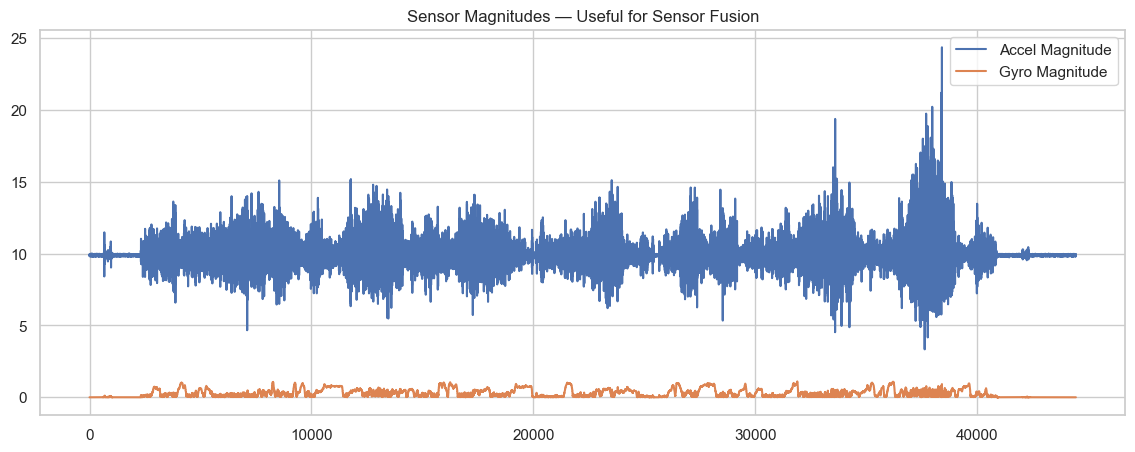

In [40]:
acc_mag = np.linalg.norm(acce, axis=1)
gyro_mag = np.linalg.norm(gyro, axis=1)

plt.figure(figsize=(14,5))
plt.plot(acc_mag, label="Accel Magnitude")
plt.plot(gyro_mag, label="Gyro Magnitude")
plt.legend()
plt.title("Sensor Magnitudes — Useful for Sensor Fusion")
plt.show()

---

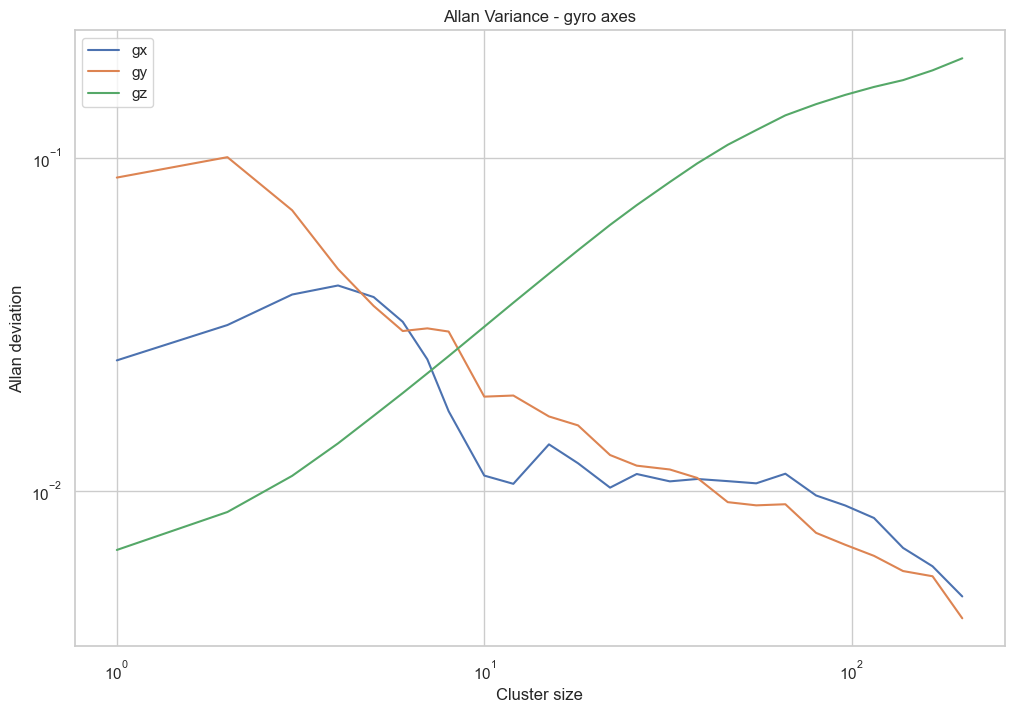

In [41]:
# Gyro Axes -- log-log plot
def allan_variance(sig, max_m=100): # Analyzes random errors / noise
    N = len(sig)
    av, taus = [], []
    for m in np.unique(np.logspace(0, np.log10(max_m), num=30, dtype=int)):
        if m<1 or m*1.0>=N:
            continue
        trimmed = (N // m) * m
        x = sig[:trimmed].reshape(-1, m).mean(axis=1)
        av.append(0.5 * np.mean(np.diff(x)**2))
        taus.append(m)

    return np.array(taus), np.array(av)

plt.figure(figsize=(12, 8))
for i, ax in enumerate(["gx", "gy", "gz"]):
    taus, av = allan_variance(gyro[:, i], max_m=200)
    plt.loglog(taus, np.sqrt(av), label=ax)
plt.xlabel("Cluster size")
plt.ylabel("Allan deviation")
plt.title("Allan Variance - gyro axes")
plt.legend()
plt.show()

Approx. Sampling Frequency:  206.4430772259684


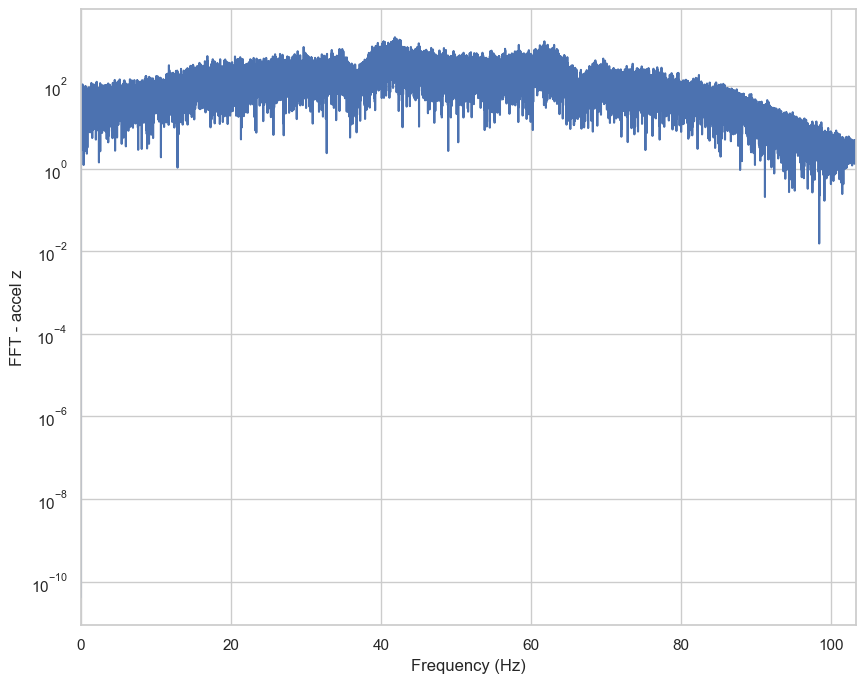

In [42]:
# FFT of accelerometer 
fs = 1.0/np.median(np.diff(timestamp)) # approx. sampling freq
print("Approx. Sampling Frequency: ", fs)

N = len(acce)
yf = rfft(acce[:,2] - np.mean(acce[:,2]))
xf = rfftfreq(N, 1/fs)

plt.figure(figsize=(10,8))
plt.semilogy(xf, np.abs(yf))
plt.xlim([0, fs/2])     # 0-100 Hz
# y-axis shows FFT magnitude in log scale
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT - accel z")
plt.show()

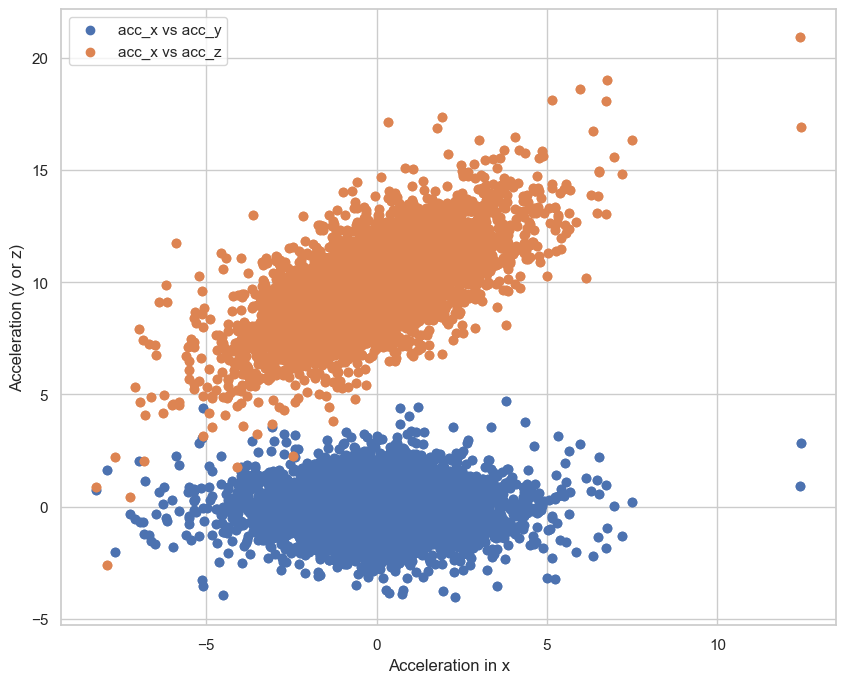

In [43]:
plt.figure(figsize=(10,8))
plt.scatter(acce[:,0], acce[:,1], label="acc_x vs acc_y")
plt.scatter(acce[:,0], acce[:,2], label="acc_x vs acc_z")
plt.legend()
plt.xlabel("Acceleration in x")
plt.ylabel("Acceleration (y or z)")
plt.show()

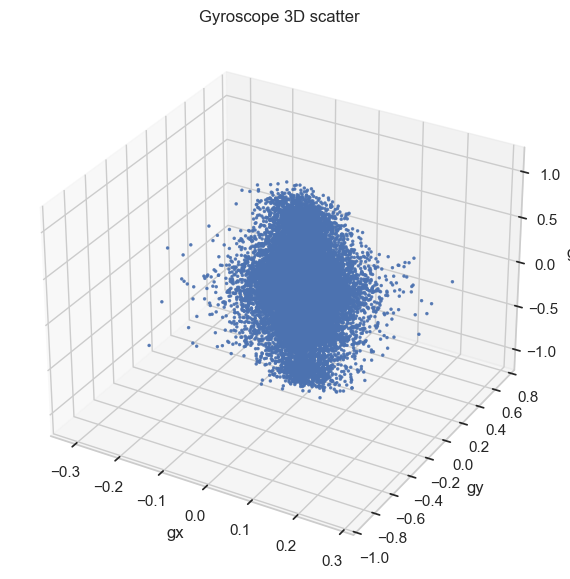

Gyro center:  [1.45638201e-05 5.60296281e-05 5.90952723e-04]


In [44]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(gyro[:, 0], gyro[:, 1], gyro[:, 2], s=2, alpha=0.6)
ax.set_xlabel("gx")
ax.set_ylabel("gy")
ax.set_zlabel("gz")
ax.set_title("Gyroscope 3D scatter")
plt.show()

center = gyro.mean(axis=0)
print("Gyro center: ", center)

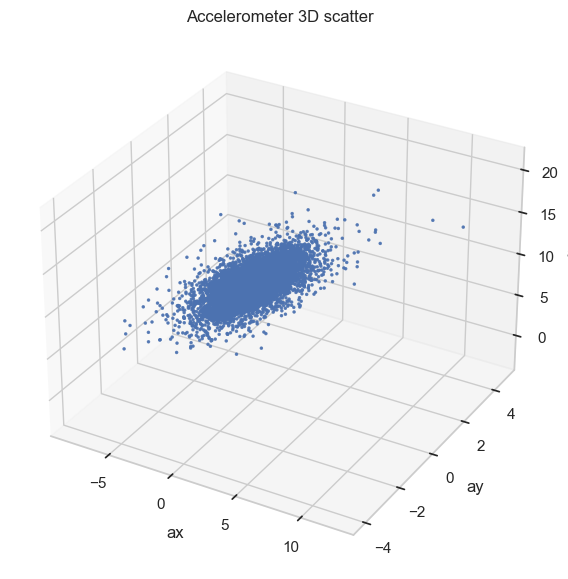

Acce center:  [ 2.93368803e-03 -6.78150117e-02  9.88372808e+00]


In [45]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(acce[:, 0], acce[:, 1], acce[:, 2], s=2, alpha=0.6)
ax.set_xlabel("ax")
ax.set_ylabel("ay")
ax.set_zlabel("az")
ax.set_title("Accelerometer 3D scatter")
plt.show()

center = acce.mean(axis=0)
print("Acce center: ", center)

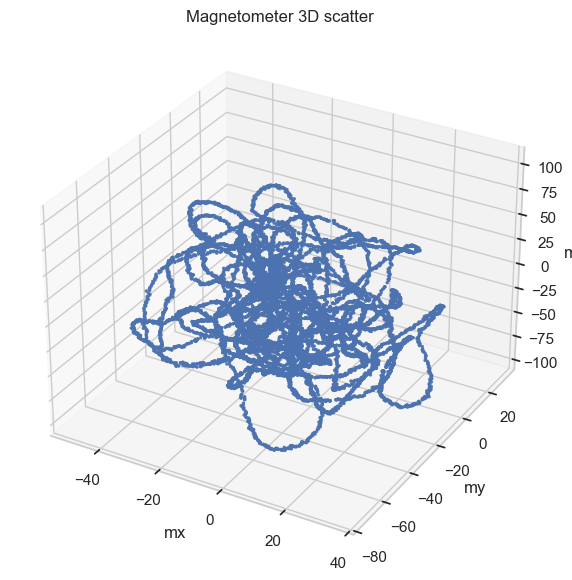

mag center:  [ -5.18721288 -21.76174546  -7.36964367]


In [46]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(mag[:, 0], mag[:, 1], mag[:, 2], s=2, alpha=0.6)
ax.set_xlabel("mx")
ax.set_ylabel("my")
ax.set_zlabel("mz")
ax.set_title("Magnetometer 3D scatter")
plt.show()

center = mag.mean(axis=0)
print("mag center: ", center)

| Plot                        | What It Reveals                                                    | What Action to Take                                                     |
| --------------------------- | ----------------------------------------------------------------------- | ----------------------------------------------------------------------- |
| **FFT (accelerometer)**     | Vibration peaks at 30–70 Hz, colored noise, energy < 50 Hz | Low-pass filter at 20–30 Hz, possible downsampling                      |
| **Allan variance (gyro)**   | Good ARW; bias instability (esp. Z-axis); drift exists     | Gyro bias estimation; use complementary/Mahony/Madgwick; EKF bias model |
| **Magnetometer 3D scatter** | Hard-iron bias; soft-iron distortion; ellipsoid shape      | Full magnetometer calibration (bias + scale + rotation)                 |


---

In [47]:
def quaternion_inverse(q):
    """Inverse of a quaternion q = [w, x, y, z]."""
    w, x, y, z = q.T
    norm_sq = w*w + x*x + y*y + z*z
    return np.column_stack((w, -x, -y, -z)) / norm_sq[:, None]

def quaternion_multiply(q1, q2):
    """Quaternion multiplication q1 ⊗ q2."""
    w1, x1, y1, z1 = q1.T
    w2, x2, y2, z2 = q2.T
    
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    
    return np.column_stack((w, x, y, z))

def compute_angular_velocity_from_quat(timestamps, quats):
    """
    Computes angular velocity (rad/s) from quaternion time series.
    timestamps: array (N,)
    quats: array (N,4) in format [w, x, y, z]
    """
    quats = np.asarray(quats)
    timestamps = np.asarray(timestamps)

    # Compute quaternion derivative dq/dt
    dq = np.diff(quats, axis=0)
    dt = np.diff(timestamps)
    dqdt = dq / dt[:, None]

    # Align sizes (dqdt is N-1)
    q_mid = quats[:-1]

    # Compute q_inv ⊗ dq/dt
    q_inv = quaternion_inverse(q_mid)
    omega_quat = quaternion_multiply(q_inv, dqdt)

    # Angular velocity is 2 * vector part (x, y, z)
    omega = 2 * omega_quat[:, 1:]  # drop scalar w
    return omega


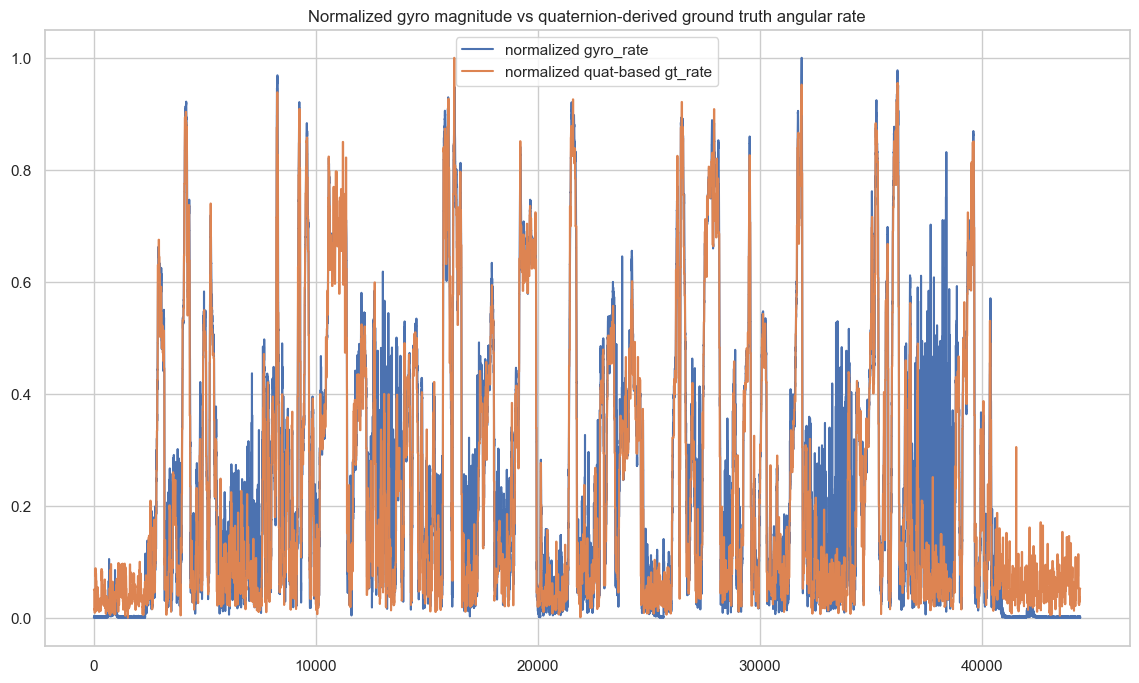

In [48]:
# Compute ground truth angular velocity from quaternions
gt_omega = compute_angular_velocity_from_quat(timestamp, quat)

# normalize for plotting
norm_gyro_mag = (gyro_mag - gyro_mag.min()) / (gyro_mag.max() - gyro_mag.min())
norm_gt_omega_mag = np.linalg.norm(gt_omega, axis=1)
norm_gt_omega_mag = (norm_gt_omega_mag - norm_gt_omega_mag.min()) / (norm_gt_omega_mag.max() - norm_gt_omega_mag.min())

plt.figure(figsize=(14,8))
plt.plot(norm_gyro_mag[:len(norm_gt_omega_mag)], label="normalized gyro_rate")
plt.plot(norm_gt_omega_mag, label="normalized quat-based gt_rate")
plt.title("Normalized gyro magnitude vs quaternion-derived ground truth angular rate")
plt.legend()
plt.show()

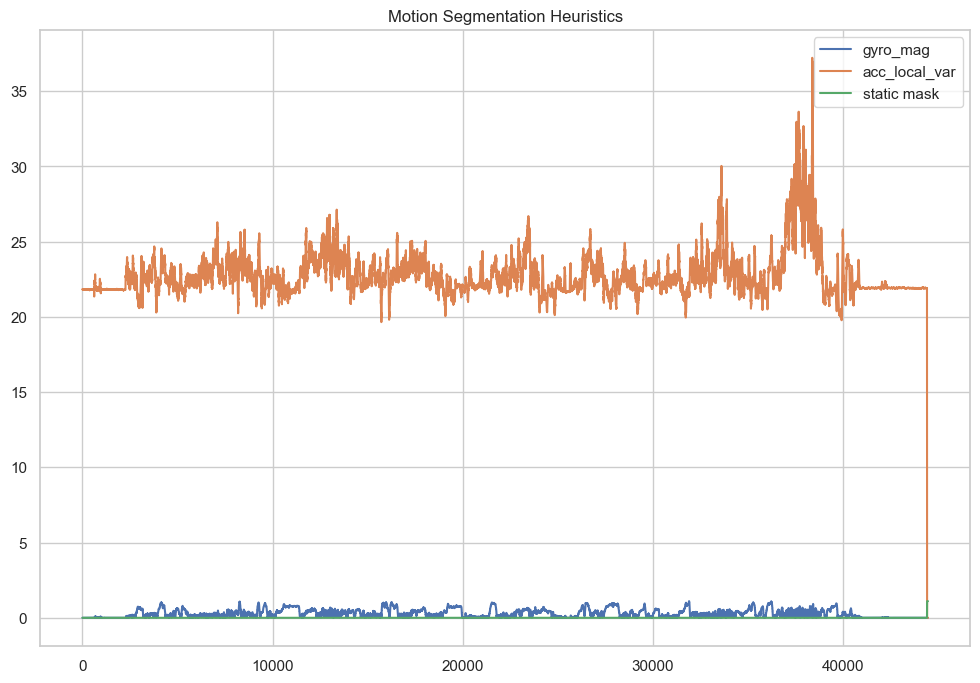

Static fraction: 0.0011023126068568344


In [49]:
# Motion segmentation
gyro_mag = np.linalg.norm(gyro, axis=1)
accel_mag = np.linalg.norm(acce, axis=1)

gyro_thresh = np.percentile(gyro_mag, 50) * 0.5
acc_var_window = 50
acc_var = np.array([acce[i:i+acc_var_window].var() if i+acc_var_window <= len(acce) else 0 for i in range(len(acce))])

static_mask = (gyro_mag < gyro_thresh) & (acc_var < np.percentile(acc_var, 50) * 0.5)

plt.figure(figsize=(12,8))
plt.plot(gyro_mag, label="gyro_mag")
plt.plot(acc_var, label="acc_local_var")
plt.plot(static_mask.astype(int) * np.max(gyro_mag), label="static mask")
plt.legend()
plt.title("Motion Segmentation Heuristics")
plt.show()

print(f"Static fraction: {static_mask.mean()}")

---

In [75]:
# Fix and apply gyro bias correction

def compute_static_mask(gyro, acc, gyro_thresh=None, acc_var_window=50, acc_var_thresh=None):
    gyro_mag = np.linalg.norm(gyro, axis=1)
    if gyro_thresh is None:
        gyro_thresh = round(np.percentile(gyro_mag, 50) * 0.5, 2)
    
    # acc_var = np.array([acc[i:i+acc_var_window].var() if i+acc_var_window <= len(acc) else 0 for i in range(len(acc))])
    # if acc_var_thresh is None:
    #     acc_var_thresh = np.percentile(acc_var, 50) * 0.5
    
    static_mask = (gyro_mag < gyro_thresh) # & (acc_var < acc_var_thresh)
    return static_mask


Calibration

✔ Fix gyro bias
✔ Accel calibration
✔ Mag calibration
✔ Gravity separation → linear acceleration

Signal processing

✔ Stationary / dynamic detection
✔ Quaternion continuity check
✔ Time resampling (if needed)

Feature engineering

✔ accel norms, gyro norms
✔ jerk
✔ angular accel
✔ windowed stats
✔ spectral features

Dataset assembly

✔ final cleaned body-frame IMU
✔ ground truth quaternions
✔ export unified dataset

In [76]:
# Accelerometer calibration
# ESTIMATE BIAS

bias_acce = acce[static_mask].mean(axis=0)
acce_corr = acce - bias_acce

scale = 9.81 / np.mean(np.abs(acce_corr[static_mask]), axis=0)
acce_scaled = acce_corr * scale

print(acce_scaled.mean(axis=0))
print(acce.mean(axis=0))

[ 0.21503759 -0.06061614  0.27619117]
[ 2.93368803e-03 -6.78150117e-02  9.88372808e+00]


In [77]:
# Gyroscope calibration

# gyro_norm = np.linalg.norm(gyro, axis=1)
# static_mask = (gyro_norm < 0.08)

gyro_bias = gyro[static_mask].mean(axis=0)
gyro_corrected = gyro - gyro_bias

print(gyro_corrected.mean(axis=0)) 
print(gyro.mean(axis=0))

[-0.0001319  -0.00030146  0.00040023]
[1.45638201e-05 5.60296281e-05 5.90952723e-04]


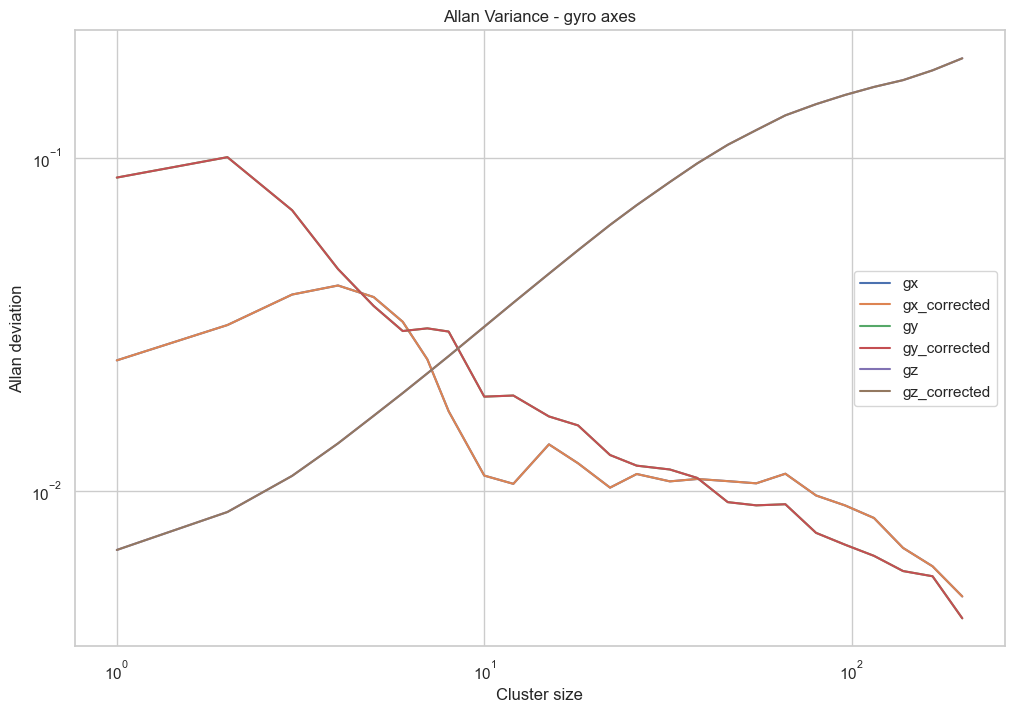

In [ ]:
# plt.figure(figsize=(12, 8))
# for i, ax in enumerate(["gx", "gy", "gz"]):
#     taus, av = allan_variance(gyro[:, i], max_m=200)
#     corr_taus, corr_av = allan_variance(gyro_corrected[:, i], max_m=200)
#     plt.loglog(taus, np.sqrt(av), label=ax)
#     plt.loglog(corr_taus, np.sqrt(corr_av), label=f"{ax}_corrected")
# plt.xlabel("Cluster size")
# plt.ylabel("Allan deviation")
# plt.title("Allan Variance - gyro axes")
# plt.legend()
# plt.show()

[ 0.04455346 -0.00101495 -0.1060429 ]
[ -5.18721288 -21.76174546  -7.36964367]


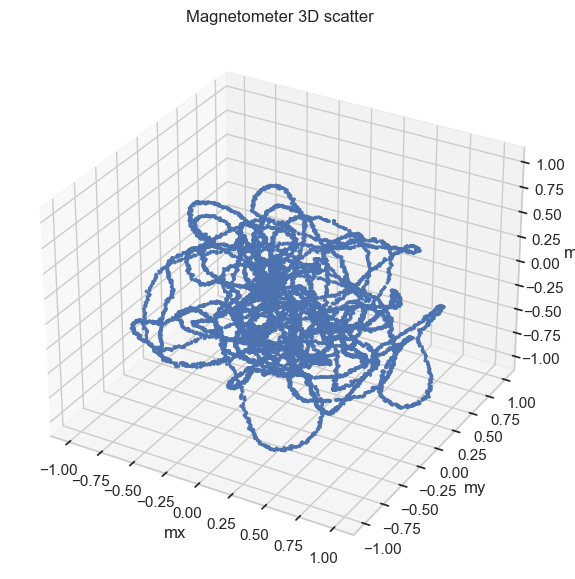

Corrected mag center:  [ 0.04455346 -0.00101495 -0.1060429 ]


In [79]:
# Magnetometer calibration

# Hard Iron calibration
offset = (mag.max(axis=0) + mag.min(axis=0)) / 2
mag_centered = mag - offset

# Soft Iron calibration
scale = (mag.max(axis=0) - mag.min(axis=0)) / 2
mag_scaled = mag_centered / scale


print(mag_scaled.mean(axis=0)) 
print(mag.mean(axis=0))


fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(mag_scaled[:, 0], mag_scaled[:, 1], mag_scaled[:, 2], s=2, alpha=0.6)
ax.set_xlabel("mx")
ax.set_ylabel("my")
ax.set_zlabel("mz")
ax.set_title("Magnetometer 3D scatter")
plt.show()

center = mag_scaled.mean(axis=0)
print("Corrected mag center: ", center)

In [82]:
print(mag.max(axis=0))
print(mag.min(axis=0))
print(mag.max(axis=0) - mag.min(axis=0))
print(mag.max(axis=0) + mag.min(axis=0))

[ 35.47500229  30.91666794 102.30834198]
[-49.64167023 -74.33333588 -96.01667023]
[ 85.11667252 105.25000381 198.32501221]
[-14.16666794 -43.41666794   6.29167175]


---

In [ ]:
# Sliding window